In [1]:
import pandas as pd 
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv(Path(Path().cwd(), "models/2025-07-22 B7H4 SAM 1000L Model/AR25-050_051_068 Model Data.csv"))
data.head()

,Sample_Name,Experiment,Batch,Sample_Time,Day,Vicell_sampletime,Flex_sampletime,Cedex_sampletime,TCC,VCC,...,DO,pH_setpoint,pH_setpoint_low,pH_setpoint_high,Temperature,Feed_Time_Offset,Bolus_Feed,Normalized_Bolus_Feed,Volume,Initial_Volume
0,AR25-050005152FER2050-01,AR25-050,AR25-050-001,5/15/2025 14:32,0,5/15/2025 14:12,5/15/2025 14:32,5/15/2025 15:40,0.6130,0.6036,...,40,7.10,6.95,7.25,36.5,0,0.0,0.0,189.01,190
1,AR25-050005152FER2051-01,AR25-050,AR25-050-002,5/15/2025 13:44,0,5/15/2025 14:19,5/15/2025 13:44,5/15/2025 15:41,0.8376,0.8333,...,40,6.75,6.60,6.90,38.0,8,0.0,0.0,189.01,190
2,AR25-050005152FER2052-01,AR25-050,AR25-050-003,5/15/2025 13:51,0,5/15/2025 14:21,5/15/2025 13:51,5/15/2025 15:42,0.7407,0.7357,...,40,7.45,7.30,7.60,35.0,-8,0.0,0.0,189.99,190
3,AR25-050005152FER2053-01,AR25-050,AR25-050-004,5/15/2025 13:58,0,5/15/2025 14:23,5/15/2025 13:58,5/15/2025 15:43,0.8061,0.7960,...,40,6.75,6.60,6.90,35.0,-8,0.0,0.0,187.21,190
4,AR25-050005152FER2054-01,AR25-050,AR25-050-005,5/15/2025 14:11,0,5/15/2025 14:25,5/15/2025 14:11,5/15/2025 15:43,0.4070,0.4055,...,40,7.45,7.30,7.60,35.0,8,0.0,0.0,187.21,190


In [45]:
y_variable = "Lactate"

x_variables = [
    # "Day",
    "TCC",
    "VCC",
    "Viability",
    "Diameter",
    "Osmolality",
    # "Ammonium",
    # "Calcium",
    "Glucose",
    "Glutamine",
    "Glutamate",
    # "Potassium",
    # "Sodium",
    # "Bicarbonate",
    "pCO2 at Temp",
    "pO2 at Temp",
    "pH at Temp",
    "IGG",
]

columns_needed = [
    # "Day",
    "TCC",
    "VCC",
    "Viability",
    "Diameter",
    "Osmolality",
    # "Ammonium",
    # "Calcium",
    "Glucose",
    "Glutamine",
    "Glutamate",
    "Lactate",
    # "Potassium",
    # "Sodium",
    # "Bicarbonate",
    "pCO2 at Temp",
    "pO2 at Temp",
    "pH at Temp",
    "IGG",
]

In [46]:
regression_data = data.loc[:, columns_needed].dropna()
X = regression_data.loc[:, x_variables]
y = regression_data.loc[:, y_variable]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
pipeline_ = Pipeline(
    [("scaler", MinMaxScaler()), ("linear", LinearRegression())]
)

In [48]:
pipeline_.fit(X=X_train, y=y_train)

# best_features = []
# for label, rank in zip(x_variables, pipeline_.named_steps["rfe"].ranking_):
#     if rank == 1:
#         best_features.append(label)

# for label, coef in zip(best_features, pipeline_.named_steps["rfe"].estimator_.coef_):
#     print(f"{label:<15}: {coef: .2f}")

Pipeline(steps=[('scaler', MinMaxScaler()), ('linear', LinearRegression())])

Text(0.5, 1.0, 'R2:  0.595')

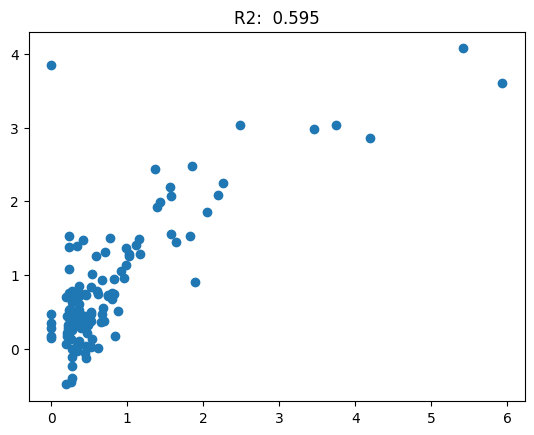

In [49]:
predictions = pipeline_.predict(X_test)
plt.scatter(y_test, predictions)
score_ = r2_score(y_test, predictions)
plt.title(f"R2: {score_: 0.3f}")

In [34]:
y_test

112    0.20
270    0.28
670    1.85
239    2.48
143    2.05
       ... 
0      0.00
712    0.33
251    0.31
456    0.48
704    0.28
Name: Lactate, Length: 185, dtype: float64

In [35]:
predictions

array([ 0.28323556,  0.40546519,  2.52428293,  2.9584659 ,  1.89072384,
        1.99859759,  0.3927466 ,  1.36557539,  0.6248223 ,  1.33133047,
        0.52846244,  0.2743193 ,  0.86406997,  0.68329   ,  3.96551359,
        0.21721122,  0.47686421,  1.06282301,  1.26551402,  1.07792553,
        2.90600631,  0.66588134,  0.48052628,  1.76630458,  0.10192703,
        0.09999658, -0.18786833,  0.06059094,  0.35544413,  0.25070087,
        0.33858829,  0.23566667,  4.40788555,  3.21289317,  1.39389732,
        2.1365338 ,  0.90366132,  0.35429954,  1.07404388, -0.21231731,
        1.04803393,  0.27810829,  0.38206047, -0.40265454,  0.51137908,
        0.31479347,  0.33506874,  2.15651923,  0.10536787,  0.80173664,
        0.66996309,  3.96133797,  0.43542968,  0.40368115,  0.28704873,
        2.61606225,  0.78845824,  2.60552907,  0.46541824,  1.08474615,
        0.88723515,  2.88022299,  0.39072656,  0.47642712,  2.63545646,
        0.0898003 ,  0.64095707,  0.27384146,  1.66199958,  0.79

In [12]:
pipeline_.named_steps["linear"].coef_

array([ 4.35424918e-15,  5.16253706e-15, -3.90221516e-15,  3.97221494e-15,
       -7.71276685e-15, -3.86737820e-15,  4.66868921e-15,  3.19734440e-15,
        2.66796178e-15, -3.30985189e-15,  5.95000000e+00,  3.06513568e-16,
        3.01056248e-15, -8.21493987e-17,  3.69947543e-16])

In [26]:
pipeline_.predict(data[x_variables])

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [27]:
data[x_variables].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Day           720 non-null    int64  
 1   TCC           720 non-null    float64
 2   VCC           720 non-null    float64
 3   Viability     720 non-null    float64
 4   Diameter      720 non-null    float64
 5   Osmolality    720 non-null    int64  
 6   Ammonium      717 non-null    float64
 7   Glucose       720 non-null    float64
 8   Glutamine     720 non-null    float64
 9   Glutamate     720 non-null    float64
 10  Lactate       619 non-null    float64
 11  pCO2 at Temp  720 non-null    float64
 12  pO2 at Temp   720 non-null    float64
 13  pH at Temp    720 non-null    float64
 14  IGG           720 non-null    float64
dtypes: float64(13), int64(2)
memory usage: 84.5 KB


In [28]:
data[x_variables]

,Day,TCC,VCC,Viability,Diameter,Osmolality,Ammonium,Glucose,Glutamine,Glutamate,Lactate,pCO2 at Temp,pO2 at Temp,pH at Temp,IGG
0,0,0.6130,0.6036,98.5,15.42,328,0.87,6.50,1.06,2.99,0.00,35.7,138.6,7.31,68.83950
1,0,0.8376,0.8333,99.5,15.15,331,0.56,2.82,0.45,1.27,0.00,52.2,151.9,7.15,66.43050
2,0,0.7407,0.7357,99.3,15.02,467,0.47,1.56,0.24,0.66,0.00,15.9,137.5,7.48,67.74885
3,0,0.8061,0.7960,98.8,15.13,330,0.67,3.79,0.60,1.74,0.00,61.9,129.1,7.11,67.04100
4,0,0.4070,0.4055,99.6,15.01,336,0.52,2.41,0.30,1.04,0.00,14.3,137.0,7.50,66.70110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,14,16.7441,14.2061,84.8,15.40,453,10.98,3.86,3.42,7.01,0.53,39.5,14.9,6.97,3422.35500
716,14,15.7493,13.9505,88.6,16.11,518,2.81,3.48,3.34,6.49,1.85,45.8,11.5,7.52,3447.39000
717,14,15.5856,13.8859,89.1,16.18,523,4.14,6.08,6.20,9.44,3.89,46.0,10.2,7.51,3454.80000
718,15,14.4070,11.2589,78.1,15.48,449,11.93,2.39,3.56,8.05,0.37,38.7,28.1,6.98,3831.76500
